# EEG-Based Age Classification — Dortmund Vital Study Resting-State EEG
## Notebook 02: Preprocessing

**Dataset:** DS005385 — Resting-state EEG data before and after cognitive activity across the adult lifespan
**Depends on:** `01_subject_subset_selection_and_data_access.ipynb` (downloads the full 416-subject cohort)

### Purpose
This notebook transforms raw EEG recordings into clean, artifact-reduced, epoched data suitable for spectral feature extraction. The pipeline is developed and validated on a single example recording, then applied systematically across the full cohort.

### Pipeline overview
1. Select EEG channels and assign standard electrode positions.
2. Remove electrical line noise and frequencies outside the range of interest (filtering).
3. Re-reference to the average of all channels.
4. Trim recording edges to avoid onset/offset artifacts.
5. Resample to reduce computational load without losing relevant frequency content.
6. Segment the continuous recording into fixed-length epochs.
7. Reject epochs contaminated by high-amplitude artifacts.

## Execution Environment: Google Colab (via VS Code)

This notebook's kernel is a remote Colab VM, connected through the Google Colab extension for VS Code. It reads the raw recordings downloaded by Notebook 01 from `/content/data/ds005385`. Colab virtual machines are temporary, so on a fresh runtime Notebooks 00 and 01 must be run first; Step 1 below checks for this and stops with a clear message if any recording is missing.

Preprocessed outputs (per-subject epoch files) are intermediate, easily regenerated artifacts and are kept on the Colab VM's disk rather than downloaded locally. Only the small summary log and figures produced along the way are retrieved for the local project folder.

In [ ]:
"""
Colab remote-kernel setup.
"""

!pip install -q mne==1.13.2

import os

%matplotlib inline
import matplotlib.pyplot as plt
import warnings
import mne
mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", message="Montage name 'standard_1020' is deprecated")

DATA_DIR = "/content/data"
FIGURES_DIR = "/content/figures"
RAW_DIR = f"{DATA_DIR}/ds005385"
PREPROCESSED_DIR = f"{DATA_DIR}/preprocessed"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

print("Data directory        :", DATA_DIR)
print("Raw EEG directory     :", RAW_DIR)
print("Figures directory     :", FIGURES_DIR)
print("Preprocessed directory:", PREPROCESSED_DIR)

Data directory        : /content/data
Raw EEG directory     : /content/data/ds005385
Figures directory     : /content/figures
Preprocessed directory: /content/data/preprocessed


## Step 1 — Locate the Cohort's Recordings

The labeled cohort is reloaded, and each subject's recording path (defined in Notebook 00, downloaded in Notebook 01) is resolved to its location on disk. The notebook confirms every recording is present before any processing begins, so a missing download surfaces immediately with a clear message rather than partway through the preprocessing loop.

In [2]:
"""
Reload the labeled cohort and confirm every subject's recording is
present on disk.
"""

import numpy as np
import pandas as pd
import mne

cohort_labels_path = f"{DATA_DIR}/cohort_labels.csv"
cohort = pd.read_csv(cohort_labels_path, dtype={"subject": str})
cohort["path"] = RAW_DIR + "/" + cohort["recording"]

missing = cohort.loc[~cohort["path"].map(os.path.exists), "subject"].tolist()
if missing:
    raise FileNotFoundError(
        f"{len(missing)} recording(s) not found on this runtime (e.g. subject {missing[0]}). "
        "Run Notebooks 00 and 01 on this Colab runtime first."
    )

print(f"All {len(cohort)} cohort recordings found on disk.")

All 416 cohort recordings found on disk.


## Step 2 — Develop the Pipeline on a Single Example Recording

Every preprocessing step below is developed and visually verified on one recording before being applied to the full cohort. This is standard practice: it is far faster to catch a mistake in a parameter choice on one recording than after running (and having to re-run) a pipeline across 416.

In [3]:
"""
Load one example recording into memory to develop the preprocessing
pipeline on.
"""

example_subject = cohort["subject"].iloc[0]
raw = mne.io.read_raw_edf(cohort["path"].iloc[0], preload=True, verbose=False)

print(f"Subject: {example_subject}")
print(raw)

Subject: 001
<RawEDF | sub-001_ses-1_task-EyesClosed_acq-pre_eeg.edf, 65 x 184000 (184.0 s), ~91.3 MiB, data loaded>


## Step 3 — Select EEG Channels and Assign Electrode Positions

Each EDF file contains the 64 scalp EEG channels listed in the dataset's `channels.tsv`, plus one non-EEG channel. Channels are selected by name: only those with a defined position in the standard 10-20 montage are kept, which retains exactly the 64 scalp electrodes and drops the non-EEG channel regardless of how it is labelled in the file. The montage then maps each retained channel name (e.g. `Fp1`, `Cz`) to a 3D scalp position, which later topographic visualization and spatially aware processing steps depend on.

In [4]:
"""
Keep only channels with a standard 10-20 position (the 64 scalp EEG
electrodes), and assign their electrode positions.
"""

montage = mne.channels.make_standard_montage("standard_1020")

eeg_channels = [ch for ch in raw.ch_names if ch in montage.ch_names]
dropped_channels = [ch for ch in raw.ch_names if ch not in montage.ch_names]

raw.pick(eeg_channels)
raw.set_montage(montage, on_missing="warn")

print(f"EEG channels retained : {len(eeg_channels)}")
print(f"Non-EEG channels dropped: {dropped_channels}")

EEG channels retained : 64
Non-EEG channels dropped: ['Status']


/tmp/ipykernel_14852/2180723199.py:6: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")


## Step 4 — Filtering

Two filtering operations are applied:

- **Notch filter at 50 Hz** removes electrical line noise from the building's power supply (this study was conducted in Germany, where mains electricity runs at 50 Hz; countries using 60 Hz mains would need a 60 Hz notch instead). Line noise appears as a narrow, very high-amplitude spike at exactly this frequency and would otherwise dominate any analysis touching nearby frequency bands.
- **Band-pass filter, 0.5-45 Hz** removes very low frequencies (slow drift from the electrode-skin interface, sweat, breathing) and very high frequencies (muscle activity, amplifier noise) while preserving the classic EEG frequency bands used later in this project (delta through low gamma, roughly 1-45 Hz).

A before/after power spectral density (PSD) comparison is plotted to visually confirm the filtering had the intended effect.

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband ed

/tmp/ipykernel_14852/1931123603.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


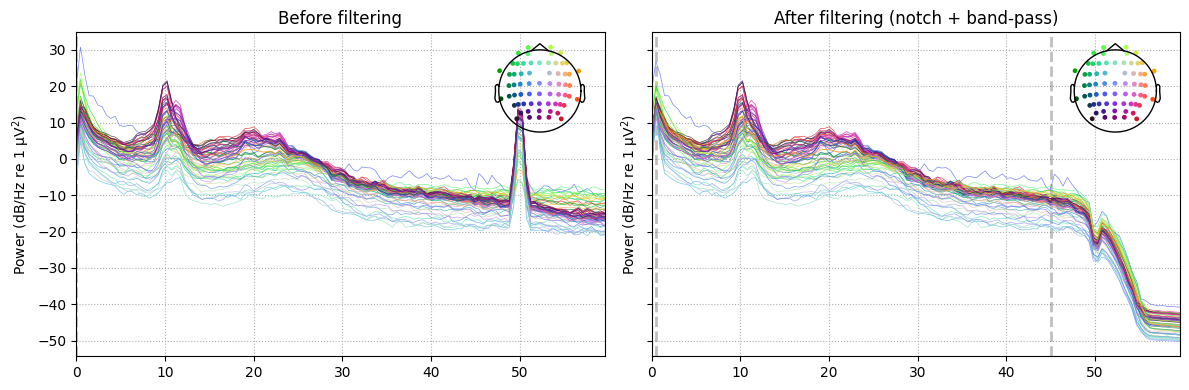

In [5]:
"""
Apply notch and band-pass filtering, and visually compare the power
spectral density before and after to confirm the expected effect:
the 50 Hz line-noise spike should disappear, and content outside
0.5-45 Hz should be attenuated.
"""

raw_unfiltered = raw.copy()

raw.notch_filter(freqs=50.0)
raw.filter(l_freq=0.5, h_freq=45.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
raw_unfiltered.compute_psd(fmax=60).plot(axes=axes[0], show=False)
axes[0].set_title("Before filtering")
raw.compute_psd(fmax=60).plot(axes=axes[1], show=False)
axes[1].set_title("After filtering (notch + band-pass)")
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/02_filtering_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — Re-referencing

EEG measures voltage *differences* between each electrode and a reference point, so every channel's recorded value is inherently shaped by whatever reference was used during acquisition. Re-referencing to the **average of all channels** removes this dependency on the original (somewhat arbitrary) recording reference and is the standard default for spectral analyses, since it does not systematically bias any particular scalp region.

In [6]:
"""
Re-reference to the average of all EEG channels.
"""

raw.set_eeg_reference(ref_channels="average")
print("Re-referenced to average.")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Re-referenced to average.


## Step 6 — Trim Recording Edges

The first and last few seconds of a recording often contain artifacts related to the participant settling into position or the experimenter's presence at the start/end of the block, rather than genuine steady-state resting activity. Three seconds are trimmed from each end.

In [7]:
"""
Trim 3 seconds from the start and end of the recording.
"""

crop_seconds = 3.0
print(f"Duration before crop: {raw.times[-1]:.1f} s")

raw.crop(tmin=crop_seconds, tmax=raw.times[-1] - crop_seconds)

print(f"Duration after crop : {raw.times[-1]:.1f} s")

Duration before crop: 184.0 s
Duration after crop : 178.0 s


## Step 7 — Resample

This recording was sampled at 1000 Hz - far higher resolution than needed for the frequency bands used later in this project (up to ~45 Hz). By the Nyquist theorem, a sampling rate of 250 Hz can still faithfully represent frequencies up to 125 Hz, comfortably covering everything of interest. Resampling to 250 Hz reduces the data volume and computation time for every subsequent step (here and in Notebook 03) by a factor of 4, with no loss of relevant information.

In [8]:
"""
Resample from 1000 Hz to 250 Hz.
"""

raw.resample(250.0)
print(f"New sampling rate: {raw.info['sfreq']} Hz")

New sampling rate: 250.0 Hz


## Step 8 — Segment into Fixed-Length Epochs

The continuous recording is split into non-overlapping 4-second windows ("epochs"). This serves two purposes: it is the format expected by the Welch's-method power spectral density estimation used in Notebook 03 (which produces a more stable estimate by averaging across many short segments rather than analyzing one long one), and it naturally produces multiple analysis windows per subject rather than a single measurement.

In [9]:
"""
Segment the continuous recording into non-overlapping 4-second epochs.
"""

epochs = mne.make_fixed_length_epochs(raw, duration=4.0, preload=True)
print(f"Epochs created: {len(epochs)}")

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 44 events and 1000 original time points ...
0 bad epochs dropped
Epochs created: 44


## Step 9 — Reject High-Amplitude Epochs

Even after filtering, brief artifacts (a small movement, a muscle twitch, residual electrode noise) can still produce epochs with abnormally large voltage swings. Any epoch where an EEG channel's peak-to-peak amplitude exceeds 150 microvolts (µV) is dropped - a commonly used threshold, since genuine resting-state EEG activity is typically in the tens-of-microvolts range, well below this cutoff.

In [10]:
"""
Reject epochs with excessive peak-to-peak amplitude in any EEG
channel, a standard artifact-rejection threshold.
"""

n_before = len(epochs)
epochs.drop_bad(reject=dict(eeg=150e-6))
n_after = len(epochs)

print(f"Epochs before rejection: {n_before}")
print(f"Epochs after rejection : {n_after}")
print(f"Rejected               : {n_before - n_after}")

    Rejecting  epoch based on EEG : ['F7']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
    Rejecting  epoch based on EEG : ['CP1']
10 bad epochs dropped
Epochs before rejection: 44
Epochs after rejection : 34
Rejected               : 10


## Step 10 — Consolidate into a Reusable Function

With every step validated on the example recording above, the full pipeline is now wrapped into a single function - avoiding duplicated code and ensuring every subject in the cohort is processed identically.

In [ ]:
"""
The full preprocessing pipeline, consolidated from the validated
steps above, as a single reusable function.
"""

def preprocess_recording(
    raw,
    l_freq: float = 0.5,
    h_freq: float = 45.0,
    notch_freq: float = 50.0,
    crop_seconds: float = 3.0,
    resample_freq: float = 250.0,
    epoch_duration: float = 4.0,
    reject_peak_to_peak: float = 150e-6,
    montage_name: str = "standard_1020",
    min_eeg_channels: int = 60,
):
    """Apply the full preprocessing pipeline to a single raw recording.

    Steps: load data into memory -> keep channels with a standard 10-20
    position -> assign montage -> notch filter -> band-pass filter ->
    average reference -> crop edges -> resample -> fixed-length
    epoching -> reject high-amplitude epochs.

    Returns
    -------
    mne.Epochs
        Cleaned, epoched data ready for spectral feature extraction.
    """
    raw = raw.copy()
    raw.load_data(verbose=False)

    montage = mne.channels.make_standard_montage(montage_name)
    eeg_channels = [ch for ch in raw.ch_names if ch in montage.ch_names]
    if len(eeg_channels) < min_eeg_channels:
        raise ValueError(f"Only {len(eeg_channels)} channels matched the {montage_name} montage")
    raw.pick(eeg_channels)
    raw.set_montage(montage, on_missing="warn")

    raw.notch_filter(freqs=notch_freq, verbose=False)
    raw.filter(l_freq=l_freq, h_freq=h_freq, verbose=False)

    raw.set_eeg_reference(ref_channels="average", verbose=False)

    raw.crop(tmin=crop_seconds, tmax=raw.times[-1] - crop_seconds)

    raw.resample(resample_freq, verbose=False)

    epochs = mne.make_fixed_length_epochs(
        raw, duration=epoch_duration, preload=True, verbose=False
    )
    epochs.drop_bad(reject=dict(eeg=reject_peak_to_peak), verbose=False)

    return epochs


# Confirm the function reproduces the step-by-step result above.
check_raw = mne.io.read_raw_edf(cohort["path"].iloc[0], verbose=False)
check_epochs = preprocess_recording(check_raw)
print(f"Function output: {len(check_epochs)} epochs (step-by-step above: {n_after})")

Reading 0 ... 183999  =      0.000 ...   183.999 secs...


/tmp/ipykernel_14852/251991813.py:33: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage(montage_name)


Function output: 34 epochs (step-by-step above: 34)


## Step 11 — Apply the Pipeline to the Full Cohort

The validated function is applied to every recording in the cohort. Each subject's preprocessed epochs are saved to disk (`.fif` format, MNE's native storage format) for use in Notebook 03. Recordings that fail are collected rather than halting the run, and MNE's own per-step logging is suppressed (`verbose=False` throughout) to keep output readable across 416 recordings - the same lesson learned from Notebook 01's download step.

In [13]:
"""
Apply preprocess_recording() to every recording in the cohort, saving
results to disk and tracking outcomes for a cohort-wide summary.
"""

preprocessing_log = []
failed_subjects = []
total = len(cohort)

for i, row in enumerate(cohort.itertuples(), start=1):
    subject_id = row.subject
    try:
        subject_raw = mne.io.read_raw_edf(row.path, verbose=False)
        subject_epochs = preprocess_recording(subject_raw)
        subject_epochs.save(
            f"{PREPROCESSED_DIR}/sub-{subject_id}-epo.fif", overwrite=True, verbose=False
        )
        preprocessing_log.append({"subject": subject_id, "n_epochs_kept": len(subject_epochs)})
    except Exception as e:
        failed_subjects.append(subject_id)
        print(f"[{i}/{total}] FAILED - subject {subject_id}: {e}")

    if i % 25 == 0 or i == total:
        print(f"[{i}/{total}] processed, {len(failed_subjects)} failure(s) so far")

print(f"\nSuccessfully preprocessed: {len(preprocessing_log)} / {total}")
if failed_subjects:
    print(f"Failed subjects: {failed_subjects}")

Reading 0 ... 183999  =      0.000 ...   183.999 secs...


/tmp/ipykernel_14852/251991813.py:33: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage(montage_name)


Reading 0 ... 183999  =      0.000 ...   183.999 secs...


/tmp/ipykernel_14852/251991813.py:33: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage(montage_name)


Reading 0 ... 183999  =      0.000 ...   183.999 secs...


...

Reading 0 ... 183999  =      0.000 ...   183.999 secs...


/tmp/ipykernel_14852/251991813.py:33: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage(montage_name)


Reading 0 ... 182999  =      0.000 ...   182.999 secs...


/tmp/ipykernel_14852/251991813.py:33: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage(montage_name)


[416/416] processed, 0 failure(s) so far

Successfully preprocessed: 416 / 416


## Step 12 — Verify Preprocessing Outcomes

A summary of surviving epoch counts across the cohort serves as a quality-control check: subjects with unusually few remaining epochs likely had a noisier-than-average recording and are worth flagging before feature extraction, rather than silently included or excluded.

In [14]:
"""
Summarize epoch counts across the cohort and flag subjects with
unusually few surviving epochs. The log is saved as a small CSV
artifact for later reference.
"""

log_df = pd.DataFrame(preprocessing_log)
print(log_df["n_epochs_kept"].describe())

low_epoch_subjects = log_df[log_df["n_epochs_kept"] < 10]
print(f"\nSubjects with fewer than 10 surviving epochs: {len(low_epoch_subjects)}")
if len(low_epoch_subjects) > 0:
    print(low_epoch_subjects)

log_path = f"{DATA_DIR}/preprocessing_log.csv"
log_df.to_csv(log_path, index=False)
print(f"\nSaved preprocessing log to {log_path}")

count    416.000000
mean      38.348558
std        9.274458
min        0.000000
25%       37.000000
50%       42.000000
75%       44.000000
max       65.000000
Name: n_epochs_kept, dtype: float64

Subjects with fewer than 10 surviving epochs: 11
    subject  n_epochs_kept
15      025              8
49      079              0
68      104              2
74      112              4
76      115              1
130     185              2
135     192              7
143     205              5
160     230              2
239     353              4
260     381              9

Saved preprocessing log to /content/data/preprocessing_log.csv


## Step 13 — Retrieve Summary Artifacts for Local Use

The preprocessing log and the filtering-comparison figure are downloaded to the local machine for the project repository. The per-subject preprocessed epoch files remain on the Colab VM's disk, since they are large, easily regenerated by re-running this notebook, and are consumed directly by Notebook 03 in the same session.


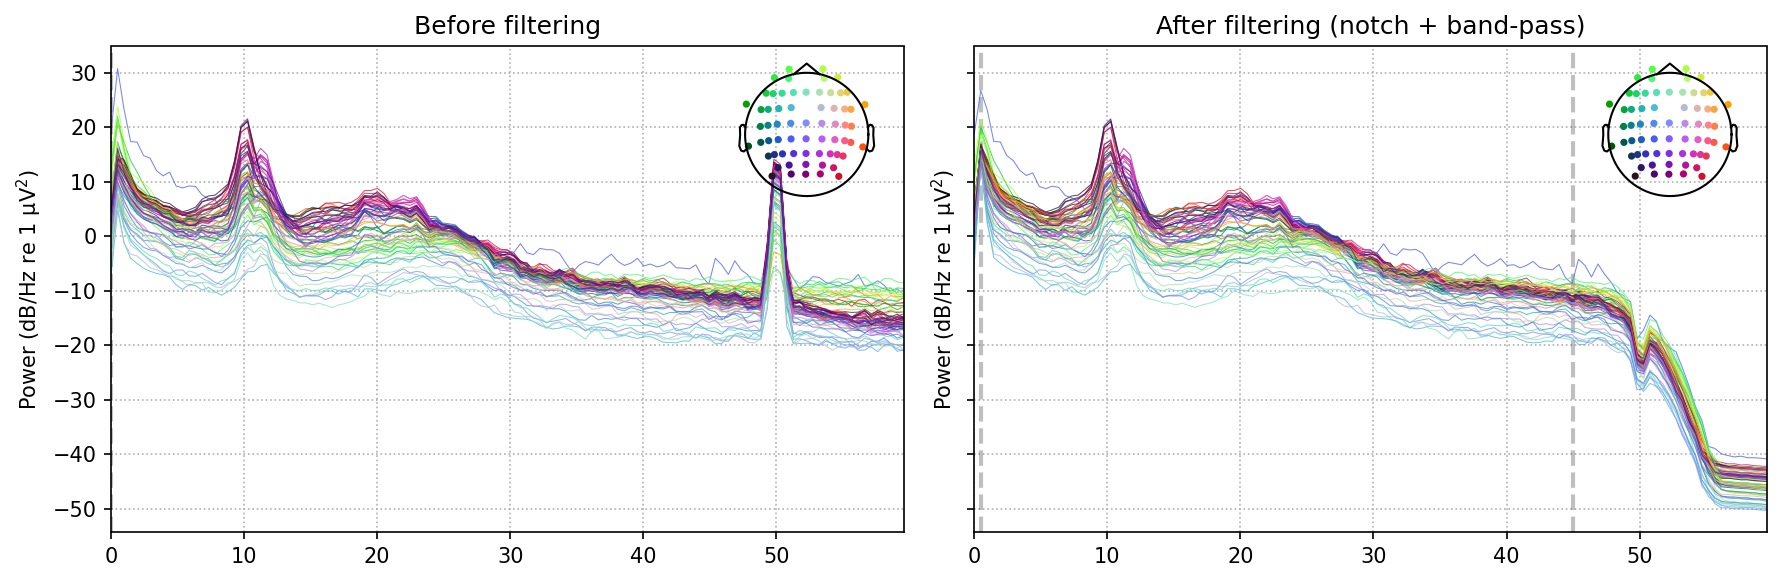

In [15]:
"""
Generate browser download links for this notebook's small, git-worthy
artifacts.
"""

import base64
import mimetypes
from IPython.display import HTML

def download_link(filepath):
    filename = filepath.split("/")[-1]
    mime_type, _ = mimetypes.guess_type(filepath)
    mime_type = mime_type or "application/octet-stream"
    with open(filepath, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return HTML(f'<a download="{filename}" href="data:{mime_type};base64,{b64}">Download {filename}</a>')

display(download_link(log_path))
display(download_link(f"{FIGURES_DIR}/02_filtering_comparison.png"))

## Summary

Every recording in the 416-subject cohort was filtered (50 Hz notch, 0.5-45 Hz band-pass), re-referenced to the average of all channels, trimmed of edge artifacts, resampled to 250 Hz, segmented into 4-second epochs, and cleaned of high-amplitude artifact epochs. Preprocessed epochs were saved per subject, and a cohort-wide log of surviving epoch counts was produced and downloaded locally for reference.

The next notebook (`03_spectral_feature_extraction.ipynb`) loads these preprocessed epochs and computes power spectral density-based band power features (delta, theta, alpha, beta, gamma) per channel, per subject - the feature representation used to train the gradient boosting classifier in Notebook 04.